In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("customer_segmentation_dataset.csv.csv")
print(df.head())

   CustomerID  Age  Annual_Income  Spending_Score  Purchase_Frequency  Gender
0           1   56          72733              36                   9  Female
1           2   46          85318              45                   7    Male
2           3   32         109474              20                  28    Male
3           4   60          43664              65                  14    Male
4           5   25          87172               8                  20    Male


In [4]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [5]:
X = df[['Age', 'Annual_Income', 'Spending_Score', 'Purchase_Frequency']]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

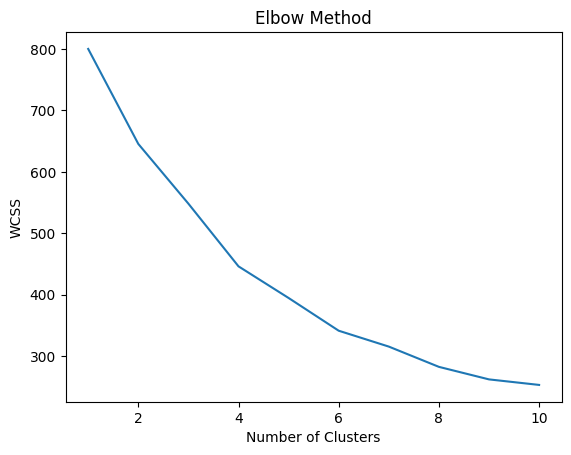

In [7]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [9]:
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

         CustomerID        Age  Annual_Income  Spending_Score  \
Cluster                                                         
0        103.878049  47.365854   51421.804878       77.292683   
1        101.787234  53.127660   49802.808511       33.000000   
2        103.288462  34.192308   79980.115385       25.230769   
3         94.766667  34.950000   82783.633333       68.483333   

         Purchase_Frequency    Gender  
Cluster                                
0                 23.292683  0.439024  
1                  9.510638  0.489362  
2                 22.250000  0.403846  
3                  9.900000  0.483333  


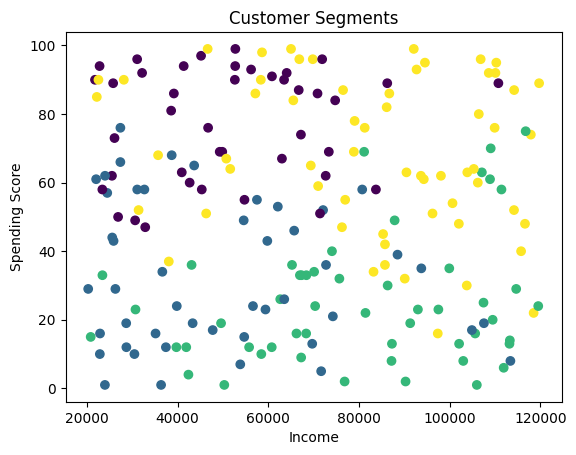

In [10]:
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()